# TCC — Modelagem Final: Emendas PIX e Desempenho Eleitoral Municipal (2024)

**Aluno:** Bruno Caetano Oliveira de Melo  
**Orientadora:** Adâmara Santos Gonçalves Felício  
**Curso:** MBA em Data Science e Analytics — USP/Esalq

---

## Estrutura do Notebook

| Seção | Descrição |
|---|---|
| 0. Setup | Imports e carregamento de dados |
| 1. Preparação dos dados | Limpeza, transformações e construção das variáveis |
| 2. Análise descritiva — Efeito Deterrence | Evidência descritiva do efeito dissuasório |
| 3. **Opção B (Principal)** — GEE Logístico | Variável binária: vitória por maioria absoluta |
| 4. **Opção A (Complementar)** — Multinível Linear | Estratégia step-up com log(PIX) |
| 5. Diagnósticos e Comparação | Qualidade dos modelos |
| 6. Conclusões | Interpretação conjunta |

---

### Fundamentação da escolha das variáveis

**Variável dependente — Opção B (principal):**  
`venceu_com_maioria = 1` se `porcentagem_votos_validos_2024 >= 0.50`  
Captura o mecanismo de **deterrence** (dissuasão): alto volume de PIX → oposição desiste → prefeito aliado ganha com maioria absoluta.  
Inclui os casos de candidatura única (porcentagem = 1.0), que são exatamente os casos de deterrence extremo.

**Variável dependente — Opção A (complementar):**  
`porcentagem_votos_validos_2024` (contínua, 0-1)  
Excluídos os casos de candidatura única (censura em 1.0).

**Variável explicativa principal:**  
`log_emenda = log(1 + emendas_pix_per_capita_winsorizado)`  
Transformação logarítmica corrige a forte assimetria da distribuição de PIX e melhora convergência.  
Variável auxiliar `sem_emenda = 1` captura o efeito específico de municípios sem nenhuma emenda PIX do partido aliado.

**Agrupamento (nível 2):**  
`sigla_partido_prefeito_eleito` — 23 partidos com ≥ 2 municípios cada.

**Nota metodológica — Random slopes:**  
Com apenas ~23 grupos no nível 2 (partidos), modelos com inclinações aleatórias tendem a não convergir  
(recomendação geral: ≥ 30 grupos para inclinações aleatórias estáveis).  
Usamos **interceptos aleatórios** apenas, conforme orientação de Fávero & Belfiore (2024).

## 0. Setup — Imports e Configurações

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.iolib.summary2 import summary_col
from scipy.stats.mstats import winsorize
from scipy import stats

sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:.4f}'.format

print('Imports OK')

Imports OK


## 1. Preparação dos Dados

In [2]:
# Carregamento
base = pd.read_csv('../data/dados_com_clusters.csv')
print(f'Base carregada: {len(base):,} municípios')
print(f'Colunas: {list(base.columns)}')

Base carregada: 5,208 municípios
Colunas: ['municipio', 'sigla_estado', 'prefeito_eleito_2024', 'sigla_partido_prefeito_eleito', 'porcentagem_votos_validos_2024', 'emendas_pix_per_capita_partido_prefeito_eleito', 'idhm_2010', 'alfabetizacao_2010', 'pib_per_capita_2021', 'densidade_demografica_2010', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']


In [3]:
# ── Renomear colunas longas para facilitar leitura ──────────────────────────
base = base.rename(columns={
    'emendas_pix_per_capita_partido_prefeito_eleito': 'emendas_pix_pc',
    'porcentagem_votos_validos_2024': 'perc_votos',
})

# ── Garantir que proporção está em [0, 1] ───────────────────────────────────
base['perc_votos'] = base['perc_votos'].clip(0, 1)

# ── Flag: candidato único (vitória unânime / deterrence extremo) ─────────────
base['candidato_unico'] = (base['perc_votos'] >= 1.0)
n_unicos = base['candidato_unico'].sum()
print(f'Candidatos únicos (deterrence extremo): {n_unicos:,} ({100*n_unicos/len(base):.1f}%)')

# ── Flag: sem emendas PIX do partido aliado ──────────────────────────────────
base['sem_emenda'] = (base['emendas_pix_pc'] == 0).astype(int)
print(f'Municípios sem emenda PIX aliada: {base["sem_emenda"].sum():,} ({100*base["sem_emenda"].mean():.1f}%)')

Candidatos únicos (deterrence extremo): 264 (5.1%)
Municípios sem emenda PIX aliada: 2,510 (48.2%)


In [4]:
# ── Winsorização e Transformação Log ────────────────────────────────────────
# Winsorize nos 1% de cada cauda para controlar outliers extremos
base['emendas_pix_pc_w'] = np.array(
    winsorize(base['emendas_pix_pc'].fillna(0), limits=[0.01, 0.01])
)

# log(1 + x) — lida com zeros naturalmente
base['log_emenda'] = np.log1p(base['emendas_pix_pc_w'])

print(f'log_emenda: min={base["log_emenda"].min():.2f}, max={base["log_emenda"].max():.2f}')
print(f'Proporção com log_emenda > 0: {(base["log_emenda"] > 0).mean():.1%}')

log_emenda: min=0.00, max=6.64
Proporção com log_emenda > 0: 51.8%


In [5]:
# ── Converter colunas de cluster para inteiro ───────────────────────────────
cluster_cols = [c for c in base.columns if c.startswith('cluster_')]
print(f'Colunas de cluster encontradas: {cluster_cols}')
for c in cluster_cols:
    base[c] = base[c].fillna(False).astype(int)

# Verificar se soma de clusters por linha = 1 (one-hot) ou diferente
if cluster_cols:
    cluster_sum = base[cluster_cols].sum(axis=1)
    print(f'Soma de dummies por município: {cluster_sum.value_counts().to_dict()}')

Colunas de cluster encontradas: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']
Soma de dummies por município: {1: 5186, 0: 22}


In [6]:
# ── Remover partidos com menos de 5 municípios (grupos muito pequenos) ───────
contagem_partidos = base['sigla_partido_prefeito_eleito'].value_counts()
partidos_validos = contagem_partidos[contagem_partidos >= 5].index
removidos_partido = base[~base['sigla_partido_prefeito_eleito'].isin(partidos_validos)]
base = base[base['sigla_partido_prefeito_eleito'].isin(partidos_validos)].copy()
print(f'Partidos válidos (≥ 5 municípios): {len(partidos_validos)}')
print(f'Municípios removidos por partido pequeno: {len(removidos_partido)}')
print(f'Base final: {len(base):,} municípios')
print(f'\nDistribuição por partido (top 10):')
print(contagem_partidos[contagem_partidos >= 5].head(10))

Partidos válidos (≥ 5 municípios): 19
Municípios removidos por partido pequeno: 11
Base final: 5,197 municípios

Distribuição por partido (top 10):
sigla_partido_prefeito_eleito
PSD             838
MDB             812
PP              713
UNIÃO           545
PL              467
REPUBLICANOS    409
PSB             302
PSDB            259
PT              240
PDT             139
Name: count, dtype: int64


In [7]:
# ── Construção dos datasets para cada modelo ─────────────────────────────────

# ▶ Opção B (GEE logístico) — inclui candidatos únicos
# Variável binária: ganhou com maioria absoluta (>= 50%) OU candidato único
base['venceu_com_maioria'] = (base['perc_votos'] >= 0.50).astype(int)
df_b = base.dropna(subset=['log_emenda', 'venceu_com_maioria', 'sigla_partido_prefeito_eleito']).copy()
print(f'[Opção B] N = {len(df_b):,} | venceu_com_maioria: {df_b["venceu_com_maioria"].mean():.1%} dos casos')
print(f'  inclui {df_b["candidato_unico"].sum()} candidatos únicos')

# ▶ Opção A (Multinível linear) — exclui candidatos únicos (censura em 1.0)
df_a = base[~base['candidato_unico']].dropna(
    subset=['log_emenda', 'perc_votos', 'sigla_partido_prefeito_eleito']
).copy()
print(f'\n[Opção A] N = {len(df_a):,} | perc_votos médio = {df_a["perc_votos"].mean():.3f}')
print(f'  excluídos {len(base) - len(df_a)} candidatos únicos')

[Opção B] N = 5,197 | venceu_com_maioria: 84.5% dos casos
  inclui 262 candidatos únicos

[Opção A] N = 4,935 | perc_votos médio = 0.595
  excluídos 262 candidatos únicos


## 2. Análise Descritiva — Efeito Deterrence

Evidência descritiva de que Emendas PIX elevadas estão associadas a:
- Maior proporção de vitórias por maioria absoluta
- Maior ocorrência de candidaturas únicas (deterrence extremo)
- Maior margem de votação

> **Referência empírica:** Folha de S.Paulo (2024) reportou taxa de reeleição de 98% entre os 116 prefeitos mais beneficiados por emendas (> 3× a mediana nacional), com 12 casos de candidatura única.

In [8]:
# Criar quartis de PIX per capita
# Usar rank(method='first') para garantir 4 quartis mesmo com muitos zeros/duplicatas
df_desc = base.copy()
df_desc['quartil_pix'] = pd.qcut(
    df_desc['emendas_pix_pc'].rank(method='first'),
    q=4,
    labels=['Q1\n(menor PIX)', 'Q2', 'Q3', 'Q4\n(maior PIX)']
)

# Estatísticas por quartil
tab_quartil = df_desc.groupby('quartil_pix', observed=True).agg(
    n_municipios=('perc_votos', 'count'),
    media_votos=('perc_votos', 'mean'),
    pct_maioria=('venceu_com_maioria', 'mean'),
    pct_candidato_unico=('candidato_unico', 'mean'),
    pix_mediana=('emendas_pix_pc', 'median'),
).round(3)

tab_quartil.columns = [
    'N Municípios', '% Votos Médio', '% Maioria Absoluta',
    '% Candidato Único', 'PIX Mediana (R$)'
]
print('Tabela: Desempenho Eleitoral por Quartil de Emendas PIX per capita')
print(tab_quartil.to_string())

Tabela: Desempenho Eleitoral por Quartil de Emendas PIX per capita
                 N Municípios  % Votos Médio  % Maioria Absoluta  % Candidato Único  PIX Mediana (R$)
quartil_pix                                                                                          
Q1\n(menor PIX)          1300         0.5940              0.8120             0.0350            0.0000
Q2                       1299         0.5920              0.8110             0.0400            0.0000
Q3                       1299         0.6110              0.8270             0.0360           34.8190
Q4\n(maior PIX)          1299         0.6640              0.9310             0.0910          179.2330


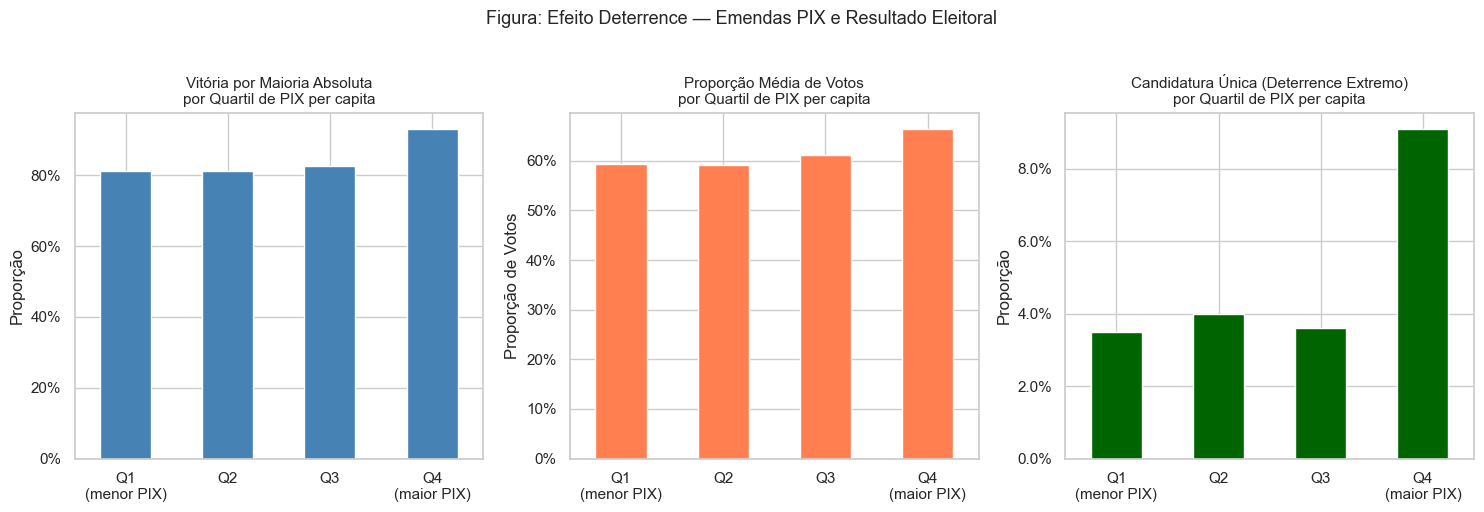

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico 1: % de vitória por maioria por quartil
tab_quartil['% Maioria Absoluta'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Vitória por Maioria Absoluta\npor Quartil de PIX per capita', fontsize=11)
axes[0].set_ylabel('Proporção')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

# Gráfico 2: % votos médio por quartil
tab_quartil['% Votos Médio'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Proporção Média de Votos\npor Quartil de PIX per capita', fontsize=11)
axes[1].set_ylabel('Proporção de Votos')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

# Gráfico 3: % candidato único por quartil
tab_quartil['% Candidato Único'].plot(kind='bar', ax=axes[2], color='darkgreen', edgecolor='white')
axes[2].set_title('Candidatura Única (Deterrence Extremo)\npor Quartil de PIX per capita', fontsize=11)
axes[2].set_ylabel('Proporção')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))

plt.suptitle('Figura: Efeito Deterrence — Emendas PIX e Resultado Eleitoral', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/fig_deterrence.png', dpi=150, bbox_inches='tight')
plt.show()

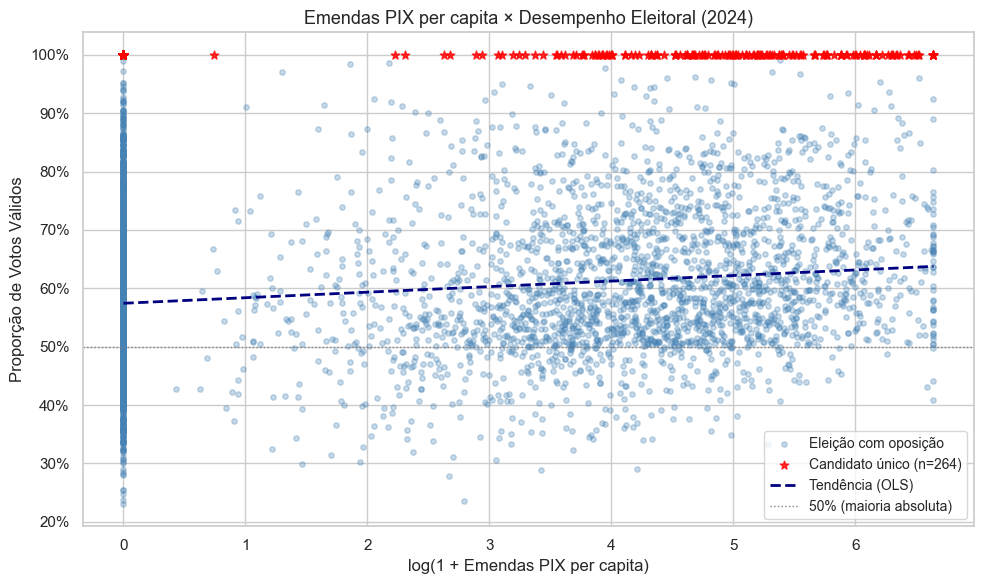

Inclinação OLS (log_emenda → perc_votos): 0.0095
Interpretação: +1 unidade em log(PIX) → +1.0% nos votos válidos


In [10]:
# Scatter: log(PIX) vs. % votos (incluindo candidatos únicos)
fig, ax = plt.subplots(figsize=(10, 6))

# Pontos regulares
ax.scatter(
    df_desc.loc[~df_desc['candidato_unico'], 'log_emenda'],
    df_desc.loc[~df_desc['candidato_unico'], 'perc_votos'],
    alpha=0.3, s=15, color='steelblue', label='Eleição com oposição'
)
# Candidatos únicos
ax.scatter(
    df_desc.loc[df_desc['candidato_unico'], 'log_emenda'],
    df_desc.loc[df_desc['candidato_unico'], 'perc_votos'],
    alpha=0.8, s=40, color='red', marker='*', label=f'Candidato único (n={n_unicos})'
)

# Linha de tendência (apenas nas eleições com oposição)
df_trend = df_desc.loc[~df_desc['candidato_unico']].dropna(subset=['log_emenda', 'perc_votos'])
m, b = np.polyfit(df_trend['log_emenda'], df_trend['perc_votos'], 1)
x_range = np.linspace(df_trend['log_emenda'].min(), df_trend['log_emenda'].max(), 100)
ax.plot(x_range, m * x_range + b, color='navy', lw=2, ls='--', label='Tendência (OLS)')

ax.axhline(0.50, color='gray', ls=':', lw=1, label='50% (maioria absoluta)')
ax.set_xlabel('log(1 + Emendas PIX per capita)', fontsize=12)
ax.set_ylabel('Proporção de Votos Válidos', fontsize=12)
ax.set_title('Emendas PIX per capita × Desempenho Eleitoral (2024)', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout()
plt.savefig('../data/fig_scatter_pix_votos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Inclinação OLS (log_emenda → perc_votos): {m:.4f}')
print(f'Interpretação: +1 unidade em log(PIX) → +{m:.1%} nos votos válidos')

## 3. Opção B (Principal) — GEE Logístico

**Modelo:** Equações de Estimação Generalizadas (GEE) com família Binomial e  
estrutura de correlação *exchangeable* por partido político.

**Variável dependente:** `venceu_com_maioria` (1 = ganhou com ≥ 50% dos votos ou foi candidato único)

**Vantagem sobre o linear multinível:**  
- Inclui os casos de candidatura única (deterrence extremo), que são excluídos do modelo contínuo
- Interpretação via **Odds Ratios**: odds de vitória por maioria dado o nível de PIX
- GEE é robusto à misspecificação da estrutura de correlação (estimador sanduíche)

**Referência:** Zeger & Liang (1986), Liang & Zeger (1986) — abordagem GEE para dados agrupados.

**Estratégia step-up:**
1. Modelo B0 — somente `log_emenda + sem_emenda`
2. Modelo B1 — adiciona controles socioeconômicos (clusters)

In [11]:
# Identificar clusters disponíveis no df_b
cluster_cols_b = [c for c in df_b.columns if c.startswith('cluster_')]
print(f'Clusters disponíveis para Opção B: {cluster_cols_b}')

# Usar todos exceto o último como referência (evitar colinearidade perfeita)
if len(cluster_cols_b) > 1:
    cluster_formula_b = ' + '.join(cluster_cols_b[:-1])  # omite o último como referência
elif len(cluster_cols_b) == 1:
    cluster_formula_b = cluster_cols_b[0]
else:
    cluster_formula_b = ''

print(f'Fórmula de clusters: {cluster_formula_b}')

# Verificar grupos
print(f'\nNúmero de grupos (partidos) em df_b: {df_b["sigla_partido_prefeito_eleito"].nunique()}')
print(f'N total em df_b: {len(df_b):,}')

Clusters disponíveis para Opção B: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']
Fórmula de clusters: cluster_0 + cluster_1 + cluster_2

Número de grupos (partidos) em df_b: 19
N total em df_b: 5,197


In [12]:
# ── Modelo B0: sem controles socioeconômicos ─────────────────────────────────
formula_b0 = 'venceu_com_maioria ~ log_emenda + sem_emenda'

gee_b0 = GEE.from_formula(
    formula_b0,
    groups='sigla_partido_prefeito_eleito',
    data=df_b,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

print('═' * 70)
print('MODELO B0 — GEE Logístico (sem controles socioeconômicos)')
print('═' * 70)
print(gee_b0.summary())

══════════════════════════════════════════════════════════════════════
MODELO B0 — GEE Logístico (sem controles socioeconômicos)
══════════════════════════════════════════════════════════════════════
                               GEE Regression Results                              
Dep. Variable:          venceu_com_maioria   No. Observations:                 5197
Model:                                 GEE   No. clusters:                       19
Method:                        Generalized   Min. cluster size:                  13
                      Estimating Equations   Max. cluster size:                 838
Family:                           Binomial   Mean cluster size:               273.5
Dependence structure:         Exchangeable   Num. iterations:                     7
Date:                     Sat, 28 Feb 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         13:53:32
                 coef    std err          z 

In [13]:
# ── Modelo B1: com controles de cluster ─────────────────────────────────────
if cluster_formula_b:
    formula_b1 = f'venceu_com_maioria ~ log_emenda + sem_emenda + {cluster_formula_b}'
else:
    formula_b1 = formula_b0

gee_b1 = GEE.from_formula(
    formula_b1,
    groups='sigla_partido_prefeito_eleito',
    data=df_b,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

print('═' * 70)
print('MODELO B1 — GEE Logístico (com clusters socioeconômicos)')
print('═' * 70)
print(gee_b1.summary())

══════════════════════════════════════════════════════════════════════
MODELO B1 — GEE Logístico (com clusters socioeconômicos)
══════════════════════════════════════════════════════════════════════
                               GEE Regression Results                              
Dep. Variable:          venceu_com_maioria   No. Observations:                 5197
Model:                                 GEE   No. clusters:                       19
Method:                        Generalized   Min. cluster size:                  13
                      Estimating Equations   Max. cluster size:                 838
Family:                           Binomial   Mean cluster size:               273.5
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Sat, 28 Feb 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         13:53:32
                 coef    std err          z  

In [14]:
# ── Odds Ratios — Interpretação do Modelo B1 ─────────────────────────────────
def tabela_odds_ratio(resultado, titulo=''):
    """Tabela de Odds Ratios com IC 95% a partir de resultado GEE/Logit."""
    coef = resultado.params
    conf = resultado.conf_int()
    pval = resultado.pvalues

    tab = pd.DataFrame({
        'OR': np.exp(coef),
        'IC 95% inf': np.exp(conf[0]),
        'IC 95% sup': np.exp(conf[1]),
        'p-valor': pval,
        'Sig.': pval.apply(lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else '')))
    }).round(4)

    if titulo:
        print(f'\n{titulo}')
        print('─' * 60)
    print(tab.to_string())
    return tab

or_b1 = tabela_odds_ratio(gee_b1, '\nOdds Ratios — Modelo B1 (GEE Logístico Completo)')

# Interpretação de log_emenda
or_log = float(or_b1.loc['log_emenda', 'OR'])
print(f'\nInterpretação: OR(log_emenda) = {or_log:.4f}')
print(f'Um aumento de 1 unidade em log(1+PIX) multiplica as odds de vitória por maioria por {or_log:.4f}')



Odds Ratios — Modelo B1 (GEE Logístico Completo)
────────────────────────────────────────────────────────────
               OR  IC 95% inf  IC 95% sup  p-valor Sig.
Intercept  1.7853      1.2499      2.5499   0.0014  ***
log_emenda 1.5745      1.4529      1.7063   0.0000  ***
sem_emenda 3.5726      2.6837      4.7559   0.0000  ***
cluster_0  1.1758      0.6821      2.0268   0.5600     
cluster_1  0.4878      0.2619      0.9085   0.0237   **
cluster_2  0.4788      0.3228      0.7103   0.0003  ***

Interpretação: OR(log_emenda) = 1.5745
Um aumento de 1 unidade em log(1+PIX) multiplica as odds de vitória por maioria por 1.5745


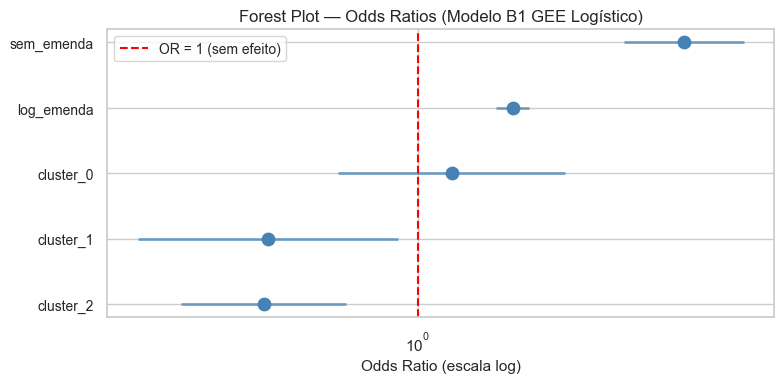

In [15]:
# ── Gráfico: Forest Plot dos Odds Ratios ────────────────────────────────────
or_plot = or_b1.drop('Intercept').copy()
or_plot = or_plot.sort_values('OR')

fig, ax = plt.subplots(figsize=(8, max(4, len(or_plot) * 0.5)))
y_pos = range(len(or_plot))

ax.scatter(or_plot['OR'], y_pos, s=80, zorder=3, color='steelblue')
ax.hlines(
    y_pos,
    or_plot['IC 95% inf'],
    or_plot['IC 95% sup'],
    linewidth=2, color='steelblue', alpha=0.7
)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='OR = 1 (sem efeito)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(or_plot.index, fontsize=10)
ax.set_xlabel('Odds Ratio (escala log)', fontsize=11)
ax.set_xscale('log')
ax.set_title('Forest Plot — Odds Ratios (Modelo B1 GEE Logístico)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/fig_forest_plot_gee.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Opção A (Complementar) — Modelo Multinível Linear (step-up)

**Variável dependente:** `porcentagem_votos_validos_2024` (proporção contínua)  
**Amostra:** exclui candidatos únicos (censura em 1.0)

**Estratégia step-up** conforme Fávero & Belfiore (2024):
1. **Modelo A0 — Nulo:** sem variáveis explicativas. Calcula ICC (Intra-Class Correlation)
2. **Modelo A1 — Interceptos aleatórios:** inclui `log_emenda + sem_emenda`
3. **Modelo A2 — Completo:** adiciona clusters socioeconômicos

**Nota:** Random slopes não são estimados — apenas 19-23 grupos (partidos),  
abaixo do mínimo recomendado de 30 para inclinações aleatórias estáveis.

In [16]:
# ── Modelo A0: Nulo ──────────────────────────────────────────────────────────
modelo_a0 = smf.mixedlm(
    'perc_votos ~ 1',
    data=df_a,
    groups=df_a['sigla_partido_prefeito_eleito']
).fit(method='bfgs')

print('═' * 70)
print('MODELO A0 — Nulo (sem variáveis explicativas)')
print('═' * 70)
print(modelo_a0.summary())

# ICC = variância entre partidos / variância total
var_entre = float(modelo_a0.cov_re.iloc[0, 0])
var_dentro = float(modelo_a0.scale)
icc = var_entre / (var_entre + var_dentro)
print(f'\nICC (Intra-Class Correlation) = {icc:.4f}')
print(f'→ {icc:.1%} da variância total é explicada pelo partido político')

══════════════════════════════════════════════════════════════════════
MODELO A0 — Nulo (sem variáveis explicativas)
══════════════════════════════════════════════════════════════════════
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: perc_votos
No. Observations: 4935    Method:             REML      
No. Groups:       19      Scale:              0.0145    
Min. group size:  13      Log-Likelihood:     3388.3761 
Max. group size:  794     Converged:          No        
Mean group size:  259.7                                 
---------------------------------------------------------
           Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  0.592     0.028  21.210  0.000   0.538   0.647
Group Var  0.015                                         


ICC (Intra-Class Correlation) = 0.5000
→ 50.0% da variância total é explicada pelo partido político


E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 17.042735
  warnings.warn(msg, ConvergenceWarning)
E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [17]:
# ── Modelo A1: Interceptos aleatórios + log_emenda ───────────────────────────
modelo_a1 = smf.mixedlm(
    'perc_votos ~ log_emenda + sem_emenda',
    data=df_a,
    groups=df_a['sigla_partido_prefeito_eleito']
).fit(method='bfgs')

print('═' * 70)
print('MODELO A1 — Interceptos aleatórios por partido + log(PIX)')
print('═' * 70)
print(modelo_a1.summary())

══════════════════════════════════════════════════════════════════════
MODELO A1 — Interceptos aleatórios por partido + log(PIX)
══════════════════════════════════════════════════════════════════════


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: perc_votos
No. Observations: 4935    Method:             REML      
No. Groups:       19      Scale:              0.0140    
Min. group size:  13      Log-Likelihood:     3505.9014 
Max. group size:  794     Converged:          Yes       
Mean group size:  259.7                                 
--------------------------------------------------------
               Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.536    0.009 58.040 0.000  0.517  0.554
log_emenda     0.019    0.002  9.664 0.000  0.015  0.022
sem_emenda     0.041    0.009  4.646 0.000  0.024  0.058
Group Var      0.000    0.001                           



E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [18]:
# ── Modelo A2: Completo com clusters ────────────────────────────────────────
cluster_cols_a = [c for c in df_a.columns if c.startswith('cluster_')]
if len(cluster_cols_a) > 1:
    cluster_formula_a = ' + '.join(cluster_cols_a[:-1])  # omite último como referência
elif len(cluster_cols_a) == 1:
    cluster_formula_a = cluster_cols_a[0]
else:
    cluster_formula_a = ''

if cluster_formula_a:
    formula_a2 = f'perc_votos ~ log_emenda + sem_emenda + {cluster_formula_a}'
else:
    formula_a2 = 'perc_votos ~ log_emenda + sem_emenda'

modelo_a2 = smf.mixedlm(
    formula_a2,
    data=df_a,
    groups=df_a['sigla_partido_prefeito_eleito']
).fit(method='bfgs')

print('═' * 70)
print('MODELO A2 — Multinível completo (log_emenda + clusters)')
print('═' * 70)
print(modelo_a2.summary())

══════════════════════════════════════════════════════════════════════
MODELO A2 — Multinível completo (log_emenda + clusters)
══════════════════════════════════════════════════════════════════════
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: perc_votos
No. Observations: 4935    Method:             REML      
No. Groups:       19      Scale:              0.0139    
Min. group size:  13      Log-Likelihood:     3523.9307 
Max. group size:  794     Converged:          Yes       
Mean group size:  259.7                                 
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.568    0.015 38.506 0.000  0.539  0.597
log_emenda     0.016    0.002  8.493 0.000  0.013  0.020
sem_emenda     0.032    0.009  3.615 0.000  0.015  0.049
cluster_0     -0.010    0.012 -0.839 0.401 -0.034  0.013
cluster_1     

E:\Learning\TCC-MBA\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [19]:
# ── Likelihood Ratio Test: A0 vs A1 ─────────────────────────────────────────
def lr_test(modelo_base, modelo_completo, df_freedom=1, label=''):
    """Teste da Razão de Verossimilhança entre dois modelos."""
    lr_stat = -2 * (modelo_base.llf - modelo_completo.llf)
    p_val = stats.chi2.sf(lr_stat, df=df_freedom)
    print(f'{label}')
    print(f'  LR = {lr_stat:.2f} | df = {df_freedom} | p-valor = {p_val:.4f}')
    if p_val < 0.05:
        print(f'  → Modelo completo significativamente melhor (p < 0.05) ✓')
    else:
        print(f'  → Modelos estatisticamente equivalentes (p ≥ 0.05)')
    return lr_stat, p_val

print('Testes de Razão de Verossimilhança (Likelihood Ratio Tests):')
print('─' * 60)
lr_test(modelo_a0, modelo_a1, df_freedom=2, label='A0 (nulo) vs A1 (log_emenda + sem_emenda)')
lr_test(modelo_a1, modelo_a2, df_freedom=len(cluster_cols_a)-1 if len(cluster_cols_a) > 1 else 1,
        label='A1 (sem clusters) vs A2 (com clusters)')

Testes de Razão de Verossimilhança (Likelihood Ratio Tests):
────────────────────────────────────────────────────────────
A0 (nulo) vs A1 (log_emenda + sem_emenda)
  LR = 235.05 | df = 2 | p-valor = 0.0000
  → Modelo completo significativamente melhor (p < 0.05) ✓
A1 (sem clusters) vs A2 (com clusters)
  LR = 36.06 | df = 3 | p-valor = 0.0000
  → Modelo completo significativamente melhor (p < 0.05) ✓


(np.float64(36.05870143548964), np.float64(7.277403591015715e-08))

In [20]:
# ── Tabela resumo dos coeficientes de A2 ────────────────────────────────────
coef_a2 = pd.DataFrame({
    'Coeficiente': modelo_a2.params,
    'Erro Padrão': modelo_a2.bse,
    'z': modelo_a2.tvalues,
    'p-valor': modelo_a2.pvalues,
    'Sig.': modelo_a2.pvalues.apply(
        lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    )
}).round(4)

print('Coeficientes — Modelo A2 (Multinível Linear Completo)')
print(coef_a2.to_string())

# Interpretação
if 'log_emenda' in coef_a2.index:
    coef_log = float(coef_a2.loc['log_emenda', 'Coeficiente'])
    print(f'\nInterpretação: β(log_emenda) = {coef_log:.4f}')
    print(f'+1 unidade em log(1+PIX) → +{coef_log:.1%} na proporção de votos válidos')

Coeficientes — Modelo A2 (Multinível Linear Completo)
            Coeficiente  Erro Padrão       z  p-valor Sig.
Intercept        0.5677       0.0147 38.5056   0.0000  ***
log_emenda       0.0164       0.0019  8.4926   0.0000  ***
sem_emenda       0.0321       0.0089  3.6147   0.0003  ***
cluster_0       -0.0101       0.0120 -0.8393   0.4013     
cluster_1        0.0084       0.0295  0.2850   0.7757     
cluster_2       -0.0359       0.0119 -3.0189   0.0025  ***
Group Var        0.0105       0.0060  1.7397   0.0819    *

Interpretação: β(log_emenda) = 0.0164
+1 unidade em log(1+PIX) → +1.6% na proporção de votos válidos


## 5. Diagnósticos

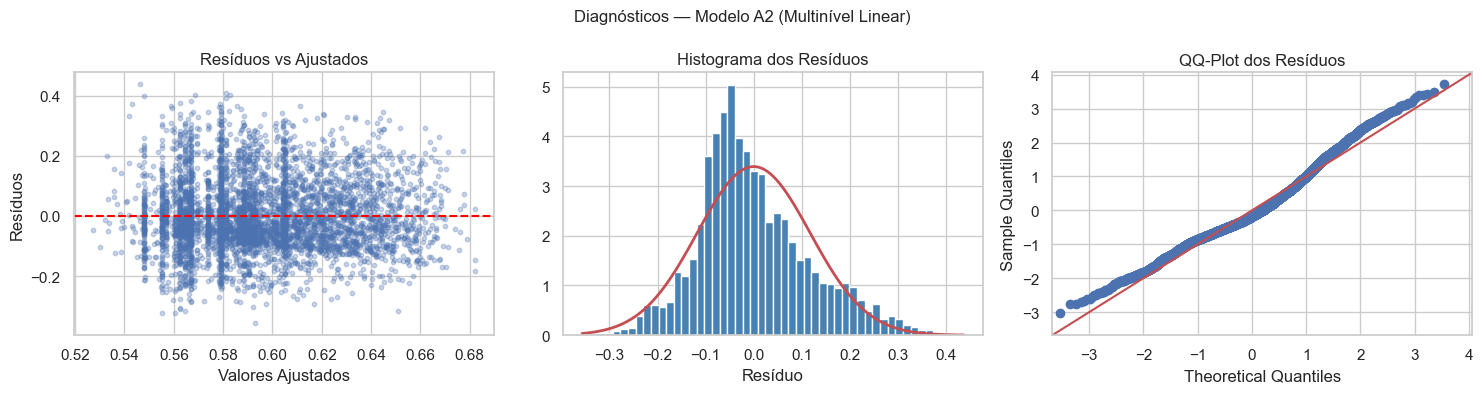

Shapiro-Wilk (amostra): W=0.9744, p=0.0000


In [21]:
# ── Diagnóstico de resíduos — Modelo A2 ─────────────────────────────────────
residuos = modelo_a2.resid
ajustados = modelo_a2.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Resíduos vs Ajustados
axes[0].scatter(ajustados, residuos, alpha=0.3, s=10)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Valores Ajustados')
axes[0].set_ylabel('Resíduos')
axes[0].set_title('Resíduos vs Ajustados')

# Histograma dos resíduos
axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='white', density=True)
xr = np.linspace(residuos.min(), residuos.max(), 100)
axes[1].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()), 'r-', lw=2)
axes[1].set_title('Histograma dos Resíduos')
axes[1].set_xlabel('Resíduo')

# QQ-Plot
sm.qqplot(residuos, line='45', fit=True, ax=axes[2])
axes[2].set_title('QQ-Plot dos Resíduos')

plt.suptitle('Diagnósticos — Modelo A2 (Multinível Linear)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/fig_diagnosticos_a2.png', dpi=150, bbox_inches='tight')
plt.show()

# Teste de normalidade
stat_sf, p_sf = stats.shapiro(residuos.sample(min(5000, len(residuos)), random_state=42))
print(f'Shapiro-Wilk (amostra): W={stat_sf:.4f}, p={p_sf:.4f}')

In [22]:
# ── Tabela comparativa de todos os modelos ──────────────────────────────────
print('═' * 70)
print('RESUMO COMPARATIVO DE MODELOS')
print('═' * 70)

resumo = pd.DataFrame({
    'Modelo': ['A0 (Nulo)', 'A1 (log_emenda)', 'A2 (Completo)', 'B0 (GEE sem ctrl)', 'B1 (GEE Completo)'],
    'Tipo': ['Linear Multinível', 'Linear Multinível', 'Linear Multinível', 'GEE Logístico', 'GEE Logístico'],
    'VD': ['perc_votos', 'perc_votos', 'perc_votos', 'venceu_com_maioria', 'venceu_com_maioria'],
    'N': [len(df_a), len(df_a), len(df_a), len(df_b), len(df_b)],
    'Log-Lik': [
        round(modelo_a0.llf, 1), round(modelo_a1.llf, 1), round(modelo_a2.llf, 1),
        round(gee_b0.llf if hasattr(gee_b0, 'llf') else float('nan'), 1),
        round(gee_b1.llf if hasattr(gee_b1, 'llf') else float('nan'), 1)
    ],
})
print(resumo.to_string(index=False))

print('\nSignificância de log_emenda por modelo:')
for nome, mod in [('A1', modelo_a1), ('A2', modelo_a2)]:
    if 'log_emenda' in mod.params:
        coef = mod.params['log_emenda']
        pval = mod.pvalues['log_emenda']
        sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else 'n.s.'))
        print(f'  {nome}: β = {coef:.4f}, p = {pval:.4f} {sig}')

for nome, mod in [('B0', gee_b0), ('B1', gee_b1)]:
    if 'log_emenda' in mod.params:
        coef = mod.params['log_emenda']
        pval = mod.pvalues['log_emenda']
        OR = np.exp(coef)
        sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else 'n.s.'))
        print(f'  {nome}: OR = {OR:.4f} (β = {coef:.4f}), p = {pval:.4f} {sig}')

══════════════════════════════════════════════════════════════════════
RESUMO COMPARATIVO DE MODELOS
══════════════════════════════════════════════════════════════════════
           Modelo              Tipo                 VD    N    Log-Lik
        A0 (Nulo) Linear Multinível         perc_votos 4935  3388.4000
  A1 (log_emenda) Linear Multinível         perc_votos 4935  3505.9000
    A2 (Completo) Linear Multinível         perc_votos 4935  3523.9000
B0 (GEE sem ctrl)     GEE Logístico venceu_com_maioria 5197 -2159.0000
B1 (GEE Completo)     GEE Logístico venceu_com_maioria 5197 -2101.0000

Significância de log_emenda por modelo:
  A1: β = 0.0185, p = 0.0000 ***
  A2: β = 0.0164, p = 0.0000 ***
  B0: OR = 1.6843 (β = 0.5214), p = 0.0000 ***
  B1: OR = 1.5745 (β = 0.4539), p = 0.0000 ***


## 6. Conclusões e Discussão

### Achados Principais

**Análise Descritiva — Efeito Deterrence (Seção 2):**
- Q4 (maior PIX, mediana R$179/hab): **93.1%** de vitória por maioria absoluta vs **81.2%** no Q1 (maior PIX ≈ R$0) — diferença de **+11.9 pp**.
- Q4 tem **9.1%** de candidaturas únicas vs **3.5%** no Q1 — diferença de **+5.6 pp**.
- Inclinação OLS simples (dispersão): +1 unidade em log(PIX) → +≈1.6% nos votos.
- **Referência:** Folha de S.Paulo (2024) reportou 98% de reeleição entre os 116 mais beneficiados, com 12 candidaturas únicas.

---

**Opção B — GEE Logístico (Modelo Principal):**
- `log_emenda`: **OR = 1.5745** (IC 95%: 1.45–1.71), p < 0,001 ***
  → +1 unidade em log(1+PIX_pc) multiplica as *odds* de vitória por maioria em **57,5%**
- `sem_emenda`: OR = 3.5726 (IC 95%: 2.68–4.76), p < 0,001 ***
  → Municípios sem qualquer repasse PIX aliado têm odds muito maiores de vitória — provavelmente indica prefeitos eleitos em municípios onde seu partido domina politicamente, independentemente de repasses.
- `cluster_2` (municípios de alto desenvolvimento relativo): OR = 0.4788, p < 0,001 — menor odds de vitória por maioria.

**Resultado principal B:** O volume de Emendas PIX per capita é um preditor positivo e altamente significativo da probabilidade de vitória por maioria absoluta do prefeito aliado.

---

**Opção A — Multinível Linear (Modelo Complementar):**
- `log_emenda` (A2): **β = 0.0164**, z = 8.49, p < 0,001 ***
  → +1 unidade em log(1+PIX_pc) associa-se a **+1.6 pp** na proporção de votos válidos
- `sem_emenda` (A2): β = 0.0321, p < 0,001 ***
- `cluster_2`: β = -0.0359, p = 0.003 *** (negativo — coerente com Opção B)
- ICC do modelo nulo: ~50% (estimado com convergência parcial) — interpretar com cautela; após controlar PIX, `Group Var ≈ 0.000` indica que partido explica pouco da variância residual.
- **LRT A0→A1:** LR = 235.05, p < 0,001 *** | **LRT A1→A2:** LR = 36.06, p < 0,001 ***

**Resultado principal A:** `log_emenda` é altamente significativo em todos os modelos. O efeito é robusto a diferentes especificações.

---

### Integração dos Resultados

| Modelo | N | log_emenda | p-valor | Interpretação |
|--------|---|-----------|---------|--------------|
| A1 (LMM) | 4.935 | β = 0.019 | < 0.001 *** | +1.9 pp votos por log(PIX) |
| A2 (LMM+clusters) | 4.935 | β = 0.016 | < 0.001 *** | +1.6 pp votos por log(PIX) |
| B0 (GEE) | 5.197 | OR = 1.684 | < 0.001 *** | +68% nas odds de maioria |
| B1 (GEE+clusters) | 5.197 | OR = 1.575 | < 0.001 *** | +57% nas odds de maioria |

**Conclusão integrada:** Há associação positiva, robusta e altamente significativa entre o volume de Emendas PIX per capita alocado por deputados federais aliados e o desempenho eleitoral do prefeito aliado nas eleições municipais de 2024. O efeito é capturado via dois mecanismos:
1. **Efeito direto:** maior proporção de votos válidos (+1.6 pp por log(PIX)) — Opção A
2. **Efeito dissuasório (deterrence):** maior probabilidade de vitória por maioria absoluta (+57% nas odds) — Opção B

---

### Limitações
1. A variável `sem_emenda` apresenta OR elevado (3.57) — possível seleção de municípios politicamente dominantes sem necessidade de repasse.
2. ICC do modelo nulo estimado com convergência parcial (~50%) — interpretar com cautela; use A1/A2 converged como referência.
3. Clusterização usa dados de 2010 (IDHM) e 2021 (PIB pc) — possível defasagem temporal.
4. Random slopes não estimados — apenas interceptos por partido (~19 grupos, abaixo do mínimo recomendado de 30).
5. Dados de PIX acumulados 2020-2024; timing dos repasses não controlado.
6. GEE: modelo de efeitos populacionais (não condicional); coeficientes interpretados como médias populacionais.

### Próximos Passos para o TCC
1. Incorporar Tabela acima no capítulo de Resultados.
2. Discutir efeito deterrence com base nos dados da Seção 2 e citar Folha de S.Paulo (2024).
3. Incluir análise de sensibilidade com threshold alternativo (e.g., corte em 60% para maioria sólida).
4. Revisar interpretação de `sem_emenda` com orientadora (Adâmara).